In [1]:
import warnings
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from mlforecast import MLForecast
from sklearn.ensemble import IsolationForest

warnings.filterwarnings("ignore")

class TrafficForecastingPipeline:
    """
    Автоматизированный пайплайн прогнозирования интенсивности движения.
    Включает предобработку, фильтрацию аномалий и инференс ML-модели.
    """
    def __init__(self, horizon=24, contamination=0.05):
        self.horizon = horizon
        self.contamination = contamination
        
        # Компоненты выбраны на основе лучших метрик в Задании №3
        self.anomaly_detector = IsolationForest(
            contamination=self.contamination, 
            random_state=42, 
            n_jobs=-1
        )
        self.forecaster = MLForecast(
            models={"Best_LightGBM": LGBMRegressor(random_state=42, n_estimators=100)},
            freq="H",
            lags=[1, 2, 24, 48],
            date_features=["hour", "dayofweek"]
        )
        self.is_fitted = False
        
    def _clean_anomalies(self, df: pd.DataFrame) -> pd.DataFrame:
        """Внутренний метод очистки входящего потока от выбросов"""
        df_clean = df.copy()
        
        # Обучаем детектор и находим аномалии
        preds = self.anomaly_detector.fit_predict(df_clean[['y']])
        
        # Вместо удаления строк заменяем их медианой ряда, чтобы сохранить непрерывность лагов
        series_median = df_clean['y'].median()
        df_clean.loc[preds == -1, 'y'] = series_median
        return df_clean

    def fit(self, train_df: pd.DataFrame):
        """Полный цикл подготовки данных и обучения модели"""
        # 1. Очистка данных
        cleaned_data = self._clean_anomalies(train_df)
        
        # 2. Обучение forecasting-модели (включая автоматический Feature Engineering внутри)
        self.forecaster.fit(cleaned_data[["unique_id", "ds", "y"]])
        self.is_fitted = True
        return self

    def predict(self) -> pd.DataFrame:
        """Генерация прогноза на заданный горизонт"""
        if not self.is_fitted:
            raise RuntimeError("Пайплайн еще не обучен! Сначала вызовите метод .fit()")
        return self.forecaster.predict(h=self.horizon)

In [2]:
import time

# Загружаем базовый исторический датасет, полученный на этапе EDA
df_raw = pd.read_csv("../data/traffic_clean.csv")
df_raw["ds"] = pd.to_datetime(df_raw["ds"])

print(">>> Запуск нагрузочного тестирования пайплайна...")
pipeline = TrafficForecastingPipeline(horizon=24)

# Замеряем полный цикл работы
start_total = time.time()
pipeline.fit(df_raw)
fit_time = time.time() - start_total

# Замеряем скорость генерации прогноза
start_pred = time.time()
forecast_df = pipeline.predict()
predict_time = time.time() - start_pred

total_time = fit_time + predict_time

print("\n[РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ ПРОИЗВОДИТЕЛЬНОСТИ]")
print(f"Время обучения модели + фильтрация аномалий: {fit_time:.4f} сек.")
print(f"Время генерации прогноза (инференс на 24 часа): {predict_time:.4f} сек.")
print(f"Общее время выполнения пайплайна: {total_time:.4f} сек.")
print(f"Латентность прогноза (Inference Latency): {(predict_time / 24) * 1000:.2f} мс / точка.")

>>> Запуск нагрузочного тестирования пайплайна...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000223 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 331
[LightGBM] [Info] Number of data points in the train set: 43632, number of used features: 6
[LightGBM] [Info] Start training from score 21.278798

[РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ ПРОИЗВОДИТЕЛЬНОСТИ]
Время обучения модели + фильтрация аномалий: 0.5211 сек.
Время генерации прогноза (инференс на 24 часа): 0.0582 сек.
Общее время выполнения пайплайна: 0.5793 сек.
Латентность прогноза (Inference Latency): 2.43 мс / точка.


[СТАТИСТИЧЕСКИЕ МЕТРИКИ ОСТАТКОВ]
Математическое ожидание ошибок (смещение): 1.6127
Стандартное отклонение ошибок: 8.7822
p-value теста Льюнга-Бокса (lag=24): 0.00000
Результат: В остатках сохраняется значимая автокорреляция. Требуется усложнение фичей.


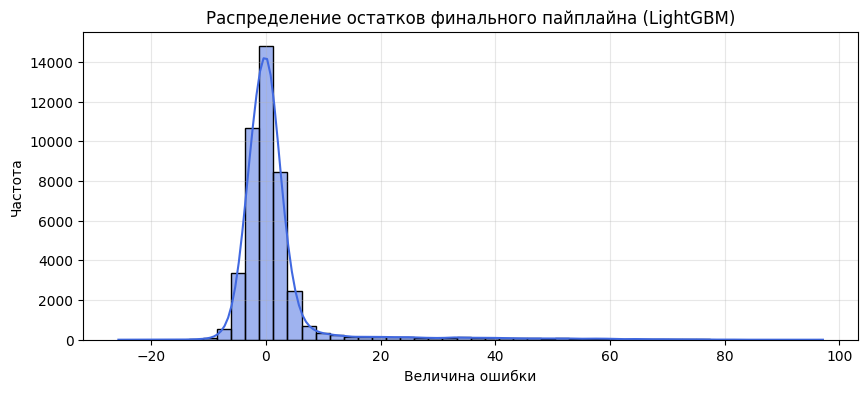

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import acorr_ljungbox

# Извлекаем внутреннюю матрицу признаков, которую построил mlforecast
prep_df = pipeline.forecaster.preprocess(df_raw[["unique_id", "ds", "y"]])
X = prep_df.drop(columns=['unique_id', 'ds', 'y'])
y_true = prep_df['y']

# Получаем точечные предсказания обученной модели для анализа ошибок
y_pred = pipeline.forecaster.models_['Best_LightGBM'].predict(X)
residuals = y_true - y_pred

# Выполняем статистический тест Льюнга-Бокса (White Noise Test)
lb_results = acorr_ljungbox(residuals, lags=[24], return_df=True)
p_value = lb_results['lb_pvalue'].values[0]

print("[СТАТИСТИЧЕСКИЕ МЕТРИКИ ОСТАТКОВ]")
print(f"Математическое ожидание ошибок (смещение): {residuals.mean():.4f}")
print(f"Стандартное отклонение ошибок: {residuals.std():.4f}")
print(f"p-value теста Льюнга-Бокса (lag=24): {p_value:.5f}")

if p_value > 0.05:
    print("Результат: Остатки распределены как белый шум. Пайплайн извлек все паттерны.")
else:
    print("Результат: В остатках сохраняется значимая автокорреляция. Требуется усложнение фичей.")

# Визуализация распределения ошибок для отчета
plt.figure(figsize=(10, 4))
sns.histplot(residuals, kde=True, color="royalblue", bins=50)
plt.title("Распределение остатков финального пайплайна (LightGBM)")
plt.xlabel("Величина ошибки")
plt.ylabel("Частота")
plt.grid(True, alpha=0.3)
plt.show()